# Predicting Customer Churn in E-Commerce

Customer churn in e-commerce is not as straightforward as it is in subscription businesses. There is no cancellation button or clear moment when a customer decides to leave. They simply stop buying. So the main question in this project is: **can we use a customer's previous purchasing behavior to identify whether they are likely to stop purchasing?**

For this project, I use the **Online Retail II** dataset, which contains transaction-level data from an online retailer. I turn these transactions into customer-level features such as recency, frequency, monetary value, purchase consistency, and recent activity.

To keep the setup realistic, I use a time-based split. Transactions before a cutoff date are used to understand each customer's behavior, while the following 90 days are used to determine whether the customer actually returned. This gives us a clear target for churn without using information from the future.

I then use **XGBoost** to estimate the probability of churn and evaluate different classification thresholds rather than automatically using 0.5. Finally, **SHAP** helps explain the predictions by showing which customer behaviors are contributing most to the estimated churn risk.

The goal is not just to predict who might churn, but to understand the signals behind that prediction and whether the results can be useful for making better retention decisions.


In [1]:
import pandas as pd 
import numpy as np
import sklearn as sk

In [4]:
df = pd.read_excel(r'D:\CV\project 3\online+retail+ii\online_retail_II.xlsx')

In [5]:
df_clean = df[
    (df["Customer ID"].notna()) &
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
]

Create the time-based split

I use the latest transaction date as the reference point and set the cutoff 90 days earlier. Transactions up to the cutoff are used to calculate customer behavior, while the following 90 days are used to determine whether a customer returned.

This keeps the churn target based on future behavior without allowing future information to enter the features.

In [7]:
T_max=df['InvoiceDate'].max()
T_c= T_max - pd.Timedelta(days=90)
obs_df = df_clean[df_clean['InvoiceDate']<=T_c]
pre_df = df_clean[df_clean['InvoiceDate']>T_c]

### Build customer-level features

I aggregate the observation period to the customer level and calculate monetary value, purchase frequency, recency, tenure, and average order value (AOV).


In [8]:
obs_df["Total_Amount"] = obs_df["Quantity"] * obs_df["Price"]

df_features = (
    obs_df.groupby("Customer ID")
    .agg(
        Monetary=("Total_Amount", "sum"),
        Frequency=("Invoice", "nunique"),
        Last_Purchase=("InvoiceDate", "max"),
        First_Purchase=("InvoiceDate", "min")
    )
    .reset_index()
)

df_features["Recency"] = (T_c - df_features["Last_Purchase"]).dt.days
df_features["Tenure"] = (T_c - df_features["First_Purchase"]).dt.days
df_features["AOV"] = df_features["Monetary"] / df_features["Frequency"]

This gives the model a clear future outcome to predict while keeping the features based only on information available before the cutoff.

In [11]:
active_customers = pre_df["Customer ID"].unique()

df_features["Churn"] = np.where(
    df_features["Customer ID"].isin(active_customers), 0, 1
)


I calculate how much each customer spent during the 30 days before the cutoff and compare it with their total spending in the observation period.

The idea is to capture recent momentum. Two customers can have similar total spending and frequency, but one may have become much less active recently. This ratio helps capture that difference.

In [12]:
recent_df = obs_df[
    obs_df["InvoiceDate"] > (T_c - pd.Timedelta(days=30))
]

recent_spending = (
    recent_df.groupby("Customer ID")["Total_Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Amount": "Spent_Last_30D"})
)

df_features = df_features.merge(
    recent_spending,
    on="Customer ID",
    how="left"
)

df_features["Spent_Last_30D"] = df_features["Spent_Last_30D"].fillna(0)

df_features["Recent_Activity_Ratio"] = (
    df_features["Spent_Last_30D"] /
    df_features["Monetary"].replace(0, 1)
).clip(0, 1)


A low value means the customer's purchases tend to happen at similar intervals, while a high value suggests more irregular behavior. I use this as an additional behavioral signal because customers with similar RFM values can still have very different purchasing patterns.

In [18]:
invoice_df = (
    obs_df[["Customer ID", "Invoice", "InvoiceDate"]]
    .drop_duplicates()
    .sort_values(["Customer ID", "InvoiceDate"])
)

invoice_df["Interval_Days"] = (
    invoice_df.groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.days
)

interval_metrics = (
    invoice_df.groupby("Customer ID")["Interval_Days"]
    .std()
    .reset_index()
    .rename(columns={"Interval_Days": "Purchase_Interval_Std"})
    .fillna(0)
)

In [15]:
df_features = df_features.drop(
    columns=["Last_Purchase", "First_Purchase"]
)


In [19]:
df_features = df_features.merge(
    interval_metrics,
    on="Customer ID",
    how="left"
)

df_features["Purchase_Interval_Std"] = (
    df_features["Purchase_Interval_Std"].fillna(0)
)

Prepare the data for modeling

I use the engineered behavioral features as inputs and split the data into training and test sets using an 80/20 split.

Stratification keeps the churn proportion similar in both sets, which is important because the classes are not evenly distributed.

In [23]:
from sklearn.model_selection import train_test_split

X = df_features[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Tenure",
        "AOV",
        "Recent_Activity_Ratio",
        "Purchase_Interval_Std"
    ]
]

y = df_features["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

I tested several classification models, including logistic regression and random forest, before selecting XGBoost for the final model. XGBoost achieved the strongest overall performance in the initial comparison, making it the most suitable choice for this analysis.

In [25]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=80,
    max_depth=2,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


I test a small range of XGBoost parameters using 5-fold cross-validation and ROC-AUC as the selection metric. The search focuses on tree depth, number of trees, learning rate, and class weighting.

The best-performing configuration is then kept as the final model.

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 3],
    "n_estimators": [80, 120, 150],
    "learning_rate": [0.02, 0.05],
    "scale_pos_weight": [1.0, 1.35]
}

base_xgb = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'learning_rate': 0.02, 'max_depth': 2, 'n_estimators': 80, 'scale_pos_weight': 1.0}
Best CV ROC-AUC: 0.7325


In [28]:
from sklearn.metrics import classification_report, roc_auc_score

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")

# ۶. ارزیابی مدل برنده روی داده‌های تست
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

Best Parameters: {'learning_rate': 0.02, 'max_depth': 2, 'n_estimators': 80, 'scale_pos_weight': 1.0}
Best CV ROC-AUC Score: 0.7325

=== Test Classification Report ===
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       389
           1       0.60      0.56      0.58       287

    accuracy                           0.66       676
   macro avg       0.65      0.65      0.65       676
weighted avg       0.66      0.66      0.66       676

Test ROC-AUC Score: 0.7192


The default 0.50 threshold is not necessarily the best choice for churn prediction. I test several thresholds to see how the balance between precision, recall, and F1-score changes.

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.38, 0.40, 0.45, 0.50]
results = []

for threshold in thresholds:
    y_pred_custom = np.where(y_pred_prob >= threshold, 1, 0)

    results.append({
        "Threshold": threshold,
        "Precision": round(precision_score(y_test, y_pred_custom), 2),
        "Recall": round(recall_score(y_test, y_pred_custom), 2),
        "F1-Score": round(f1_score(y_test, y_pred_custom), 2)
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.to_string(index=False))

 Threshold  Precision  Recall  F1-Score
      0.30       0.51    0.90      0.65
      0.35       0.54    0.83      0.66
      0.38       0.55    0.81      0.65
      0.40       0.55    0.78      0.65
      0.45       0.57    0.68      0.62
      0.50       0.60    0.56      0.58


I select 0.35 as the final classification threshold based on the trade-off observed in the threshold comparison.

Lowering the threshold makes the model more willing to flag customers as likely to churn. This improves the chances of catching at-risk customers, but also increases false positives. The confusion matrix shows the resulting trade-off at the selected threshold.

In [30]:
from sklearn.metrics import confusion_matrix

final_threshold = 0.35

y_pred_final = np.where(y_pred_prob >= final_threshold, 1, 0)

print(f"=== Final Classification Report (Threshold = {final_threshold}) ===")
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0 (Active)", "Actual 1 (Churn)"],
    columns=["Pred 0 (Active)", "Pred 1 (Churn)"]
)

print("\n=== Confusion Matrix ===")
print(cm_df)

=== Final Classification Report (Threshold = 0.35) ===
              precision    recall  f1-score   support

           0       0.79      0.48      0.60       389
           1       0.54      0.83      0.66       287

    accuracy                           0.63       676
   macro avg       0.67      0.66      0.63       676
weighted avg       0.69      0.63      0.62       676


=== Confusion Matrix ===
                   Pred 0 (Active)  Pred 1 (Churn)
Actual 0 (Active)              186             203
Actual 1 (Churn)                48             239


In [31]:
test_df = X_test.copy()

test_df["Churn_Probability"] = y_pred_prob

test_df["Risk_Segment"] = np.where(
    test_df["Churn_Probability"] >= final_threshold,
    "At Risk",
    "Safe"
)

In [ ]:
test_df.groupby("Risk_Segment")[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Purchase_Interval_Std",
        "Churn_Probability"
    ]
].mean().round(2)

,Recency,Frequency,Monetary,Purchase_Interval_Std,prob
Risk_Segment,,,,,
at risk,118.13,1.60,615.24,3.38,0.52
safe,38.18,6.99,2995.65,32.82,0.25


At-risk customers show weaker purchasing behavior than safe customers:

They purchased less recently.
They made fewer purchases.
They spent less money overall.

This supports the model's risk classification. However, purchase interval variability is higher for safe customers, not at-risk customers.

In [32]:
pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

Purchase_Interval_Std    0.419571
Frequency                0.203951
Monetary                 0.188334
Recency                  0.084712
AOV                      0.059381
Tenure                   0.044051
Recent_Activity_Ratio    0.000000
dtype: float32

I check the model's feature importance to see which customer behaviors contribute most to the model's decisions.

The engineered features contribute meaningfully to the model, especially Purchase_Interval_Std, which has the highest feature importance. Frequency and Monetary also have a strong influence, while Recent_Activity_Ratio does not contribute to the model in this configuration.

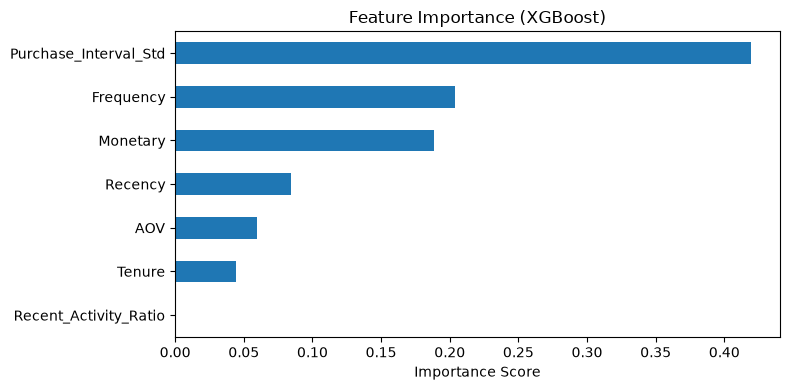

In [33]:
import matplotlib.pyplot as plt

feat_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values()

feat_importance.plot(
    kind="barh",
    figsize=(8, 4)
)

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Feature importance tells me which features the model uses most, but not how they affect individual predictions.

This is where SHAP comes in. It shows how each feature pushes a prediction higher or lower compared with the model's baseline.

The summary plot also helps me see which features have the biggest overall impact and whether higher or lower feature values are associated with higher churn risk.

This helps answer more practical questions: What kind of behavior is linked to churn? What reduces predicted risk? And why did the model flag a particular customer?

C:\Users\ENVY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


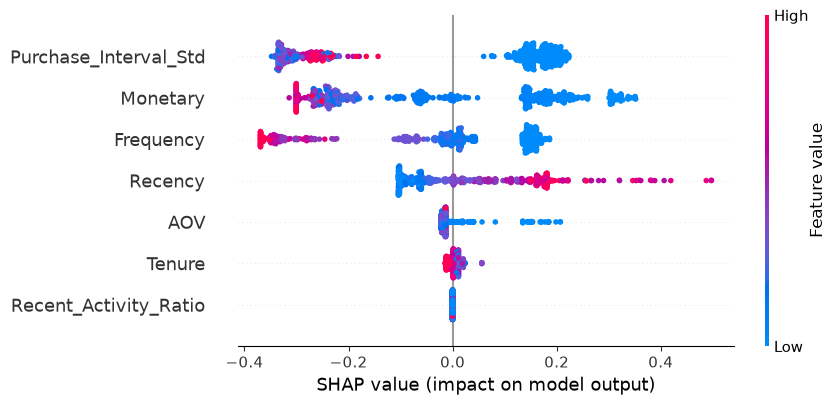

In [36]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

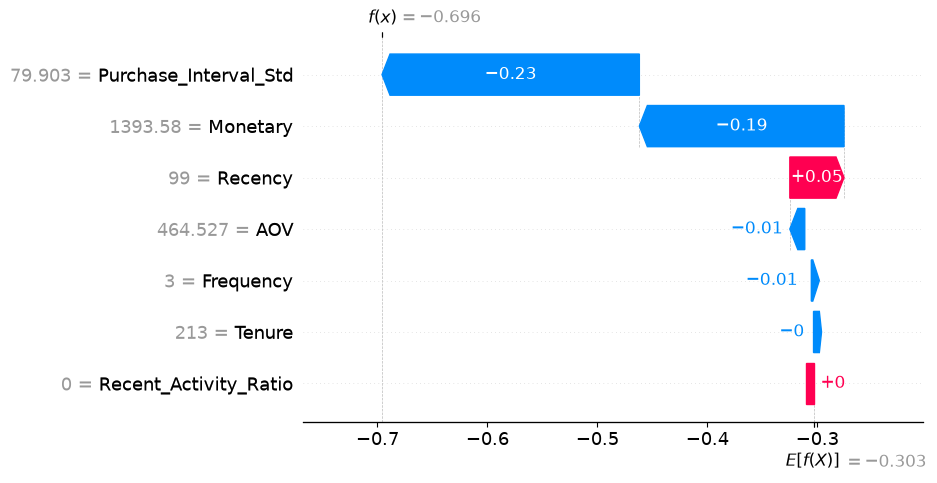

In [37]:
shap.plots.waterfall(shap_values[0])

In [38]:
shap_values_obj = explainer(X)
shap_vals = shap_values_obj.values

feature_names = X.columns

top_factor_1_list, top_shap_1_list = [], []
top_factor_2_list, top_shap_2_list = [], []
risk_insights = []

insight_map = {
    "Recency": "long time since last purchase",
    "Frequency": "low purchase frequency",
    "Monetary": "low historical spending",
    "AOV": "low average order value",
    "Purchase_Interval_Std": "irregular purchase behavior",
    "Tenure": "short customer tenure",
    "Recent_Activity_Ratio": "declining recent activity"
}

for i in range(len(X)):
    customer_risks = [
        (name, shap_value)
        for name, shap_value in zip(feature_names, shap_vals[i])
        if shap_value > 0
    ]

    customer_risks.sort(key=lambda x: x[1], reverse=True)

    if not customer_risks:
        top_factor_1_list.append("None")
        top_shap_1_list.append(0.0)
        top_factor_2_list.append("None")
        top_shap_2_list.append(0.0)
        risk_insights.append(
            "No major behavioral factor is increasing the model's churn risk."
        )
        continue

    feat_1, val_1 = customer_risks[0]
    top_factor_1_list.append(feat_1)
    top_shap_1_list.append(val_1)

    reason_1 = insight_map.get(feat_1, "unknown factor")

    if len(customer_risks) > 1:
        feat_2, val_2 = customer_risks[1]
        top_factor_2_list.append(feat_2)
        top_shap_2_list.append(val_2)

        reason_2 = insight_map.get(feat_2, "unknown factor")
        risk_insights.append(
            f"{reason_1.capitalize()} and {reason_2} are increasing churn risk."
        )
    else:
        top_factor_2_list.append("None")
        top_shap_2_list.append(0.0)
        risk_insights.append(
            f"{reason_1.capitalize()} is increasing churn risk."
        )

I use the SHAP values to identify the strongest factors increasing churn risk for each customer. The top two positive SHAP values are kept along with a simple explanation that can be used later when looking at individual customers.

The final output combines the churn probability with these risk factors and is saved as a separate file for the next stage of the analysis.

In [39]:
df_xgb_export = pd.DataFrame({
    "Customer ID": df_features["Customer ID"],
    "Churn_Probability": best_xgb.predict_proba(X)[:, 1],
    "Top_Risk_Factor_1": top_factor_1_list,
    "Top_Risk_SHAP_1": top_shap_1_list,
    "Top_Risk_Factor_2": top_factor_2_list,
    "Top_Risk_SHAP_2": top_shap_2_list,
    "Marketing_Insight": risk_insights
})

df_xgb_export.to_csv(
    "xgb_churn_predictions_v3.csv",
    index=False
)

print("Export complete. File saved as 'xgb_churn_predictions_v3.csv'")

Export complete. File saved as 'xgb_churn_predictions_v3.csv'


In [40]:
df_xgb_export.head()

,Customer ID,Churn_Probability,Top_Risk_Factor_1,Top_Risk_SHAP_1,Top_Risk_Factor_2,Top_Risk_SHAP_2,Marketing_Insight
0,12346.0,0.401386,Monetary,0.214756,AOV,0.206963,Low historical spending and low average order ...
1,12349.0,0.430360,Purchase_Interval_Std,0.175768,Recency,0.048944,Irregular purchase behavior and long time sinc...
2,12355.0,0.492395,Purchase_Interval_Std,0.180680,Frequency,0.151050,Irregular purchase behavior and low purchase f...
3,12358.0,0.424117,Purchase_Interval_Std,0.175768,Recency,0.050647,Irregular purchase behavior and long time sinc...
4,12359.0,0.249850,Recency,0.046736,None,0.000000,Long time since last purchase is increasing ch...
